# Fashion-MNIST: MLP from Scratch with PyTorch
**Covers:** Tensors → MLP architecture → Loss → Optimizer → Backpropagation → Training loop

Dataset: Fashion-MNIST (10 classes, 28×28 grayscale images)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. What is a Tensor?

A **tensor** is just an n-dimensional array — like numpy arrays, but with two superpowers:
- Can run on GPU
- Tracks gradients automatically (this is what makes backprop possible)

```
scalar  → 0D tensor  → torch.tensor(5.0)
vector  → 1D tensor  → torch.tensor([1.0, 2.0, 3.0])
matrix  → 2D tensor  → torch.tensor([[1,2],[3,4]])
image   → 3D tensor  → shape (C, H, W)
batch   → 4D tensor  → shape (N, C, H, W)
```

When you set `requires_grad=True`, PyTorch builds a **computation graph** as operations happen.
When you call `.backward()`, it walks that graph backwards to compute gradients. That's backprop.

In [2]:
x = torch.tensor(3.0, requires_grad=True)   # a 'weight' we want to learn
y = x ** 2 + 2 * x + 1                      # some computation
y.backward()                                 # compute dy/dx
print(f"x = {x.item()}, y = {y.item()}, dy/dx = {x.grad.item()}")  # should be 2x+2 = 8

x = 3.0, y = 16.0, dy/dx = 8.0


## 2. Load the Data (from CSV)

In [3]:
# Fashion-MNIST CSVs: first column = label, remaining 784 = pixel values (0-255)
train_df = pd.read_csv('fashion-mnist_train.csv')
test_df  = pd.read_csv('fashion-mnist_test.csv')

print(f"Train shape: {train_df.shape}")  # (60000, 785)
print(f"Test shape:  {test_df.shape}")   # (10000, 785)
print(f"Classes: {sorted(train_df['label'].unique())}")

Train shape: (60000, 785)
Test shape:  (10000, 785)
Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


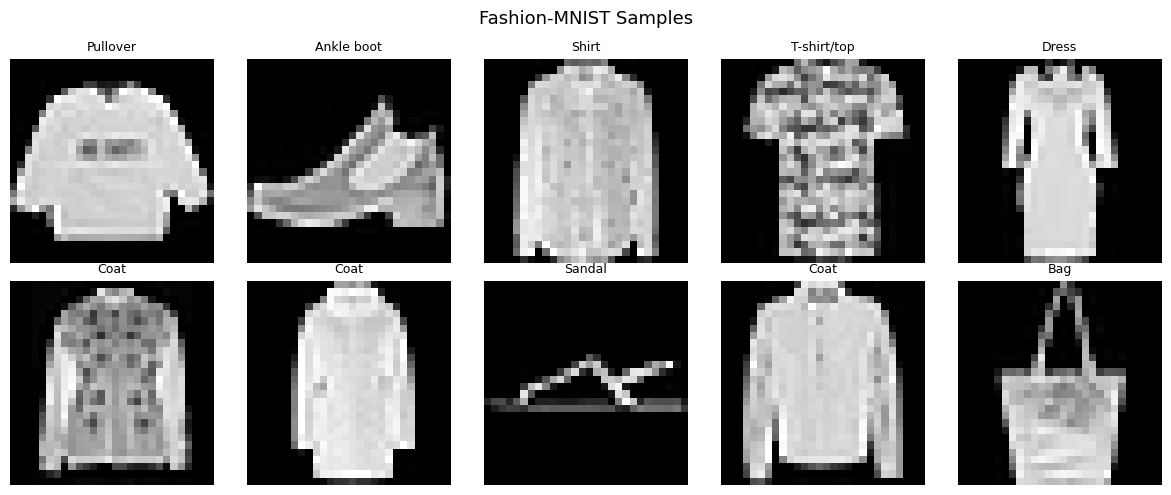

In [ ]:
CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    row = train_df.iloc[i]
    label = int(row['label'])
    pixels = row.drop('label').values.reshape(28, 28)
    ax.imshow(pixels, cmap='gray')
    ax.set_title(CLASS_NAMES[label], fontsize=9)
    ax.axis('off')
plt.suptitle('Fashion-MNIST Samples', fontsize=13)
plt.tight_layout()

## 3. Custom Dataset + DataLoader

PyTorch's `Dataset` class wraps your data so `DataLoader` can:
- Shuffle it every epoch
- Serve it in mini-batches
- Load it in parallel (num_workers)

You only need to implement `__len__` and `__getitem__`.

In [5]:
class FashionDataset(Dataset):
    def __init__(self, df):
        # Separate labels from pixel values
        self.labels = torch.tensor(df['label'].values, dtype=torch.long)
        
        # Pixel values → float32 → normalize to [0, 1]
        # Normalization helps gradient flow stay stable during training
        pixels = df.drop('label', axis=1).values.astype(np.float32)
        self.images = torch.tensor(pixels / 255.0)  # shape: (N, 784)

    def __len__(self):
        # How many samples total
        return len(self.labels)

    def __getitem__(self, idx):
        # Return one (image, label) pair by index
        return self.images[idx], self.labels[idx]


# Build datasets
train_dataset = FashionDataset(train_df)
test_dataset  = FashionDataset(test_df)

# DataLoaders — batch_size=64 is a good default
# shuffle=True for train (important! prevents the model memorizing order)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

# Verify shape
images, labels = next(iter(train_loader))
print(f"Batch images shape: {images.shape}")  # (64, 784)
print(f"Batch labels shape: {labels.shape}")  # (64,)

Batch images shape: torch.Size([64, 784])
Batch labels shape: torch.Size([64])


## 4. MLP Architecture

```
Input: 784 (flattened 28×28 image)
  ↓  Linear(784 → 256)
  ↓  ReLU          ← activation: adds non-linearity
  ↓  Dropout(0.3)  ← randomly zeros neurons during training (regularization)
  ↓  Linear(256 → 128)
  ↓  ReLU
  ↓  Dropout(0.3)
  ↓  Linear(128 → 10)
Output: 10 raw scores (logits), one per class
```

No softmax at the end — `CrossEntropyLoss` applies it internally (more numerically stable).

**Why ReLU?**  
Without activations, stacking linear layers = still just one linear layer. ReLU (max(0, x)) breaks linearity, letting the network learn complex decision boundaries.

**Why Dropout?**  
Forces the network to not rely on any single neuron. Reduces overfitting.

In [ ]:
class MLP(nn.Module):
    def __init__(self, input_dim=784, hidden1=256, hidden2=128, num_classes=10, dropout=0.3):
        super(MLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),                   
            nn.Dropout(dropout),  
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, num_classes)
        )
    def forward(self, x):
        return self.network(x)
model = MLP()
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

MLP(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total parameters: 235,146


## 5. Loss Function

**CrossEntropyLoss** = Softmax + Negative Log Likelihood in one step.

Softmax turns raw logits into probabilities (sum to 1):
```
P(class_i) = exp(logit_i) / sum(exp(logit_j))
```

Then NLL Loss penalizes the model based on how low the probability was for the *correct* class:
```
Loss = -log(P(correct class))
```

If the model is confident and correct → loss ≈ 0  
If the model is confident and wrong  → loss is very high  

## 6. Optimizer

The optimizer decides **how** to update weights after gradients are computed.

**SGD:** `w = w - lr * gradient`  
**Adam:** Adaptive — maintains per-parameter learning rates, uses momentum. Usually converges faster.

`lr=0.001` is a safe default for Adam.

In [7]:
# Loss function
criterion = nn.CrossEntropyLoss()  
# Input: raw logits (N, 10) + labels (N,)
# Output: scalar loss value

# Optimizer — pass model.parameters() so it knows what to update
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Device setup — use GPU if available (MPS for Mac, CUDA for NVIDIA)
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

model = model.to(device)
print(f"Using device: {device}")

Using device: mps


## 7. Backpropagation — What Actually Happens

Every training step has **4 key lines**:

```python
optimizer.zero_grad()   # 1. Clear old gradients (they accumulate otherwise)
outputs = model(x)      # 2. Forward pass — compute predictions
loss = criterion(...)   # 3. Compute loss
loss.backward()         # 4. Backprop — compute gradients via chain rule
optimizer.step()        # 5. Update weights using those gradients
```

**What `loss.backward()` does:**  
Walks the computation graph backwards from the loss, applying the **chain rule** at every operation to compute `dLoss/dWeight` for every parameter. PyTorch does this automatically — you built the graph during the forward pass.

**Why `zero_grad()` first?**  
PyTorch accumulates gradients by default (useful for some techniques). For a standard training loop you want fresh gradients each step, so clear them first.

## 8. Training Loop

In [8]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Run one full pass over the training data."""
    model.train()  # IMPORTANT: enables Dropout, BatchNorm training behavior
    
    total_loss = 0
    correct    = 0
    total      = 0

    for images, labels in loader:
        # Move data to same device as model
        images, labels = images.to(device), labels.to(device)

        # --- THE CORE 5 LINES ---
        optimizer.zero_grad()              # 1. Clear gradients from last step
        outputs = model(images)            # 2. Forward pass → logits shape: (64, 10)
        loss = criterion(outputs, labels)  # 3. Compute cross entropy loss
        loss.backward()                    # 4. Backprop → fills .grad for every parameter
        optimizer.step()                   # 5. Update: w = w - lr * w.grad
        # ------------------------

        # Track metrics
        total_loss += loss.item() * images.size(0)  # unnormalize
        preds = outputs.argmax(dim=1)               # predicted class = highest logit
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


def evaluate(model, loader, criterion, device):
    """Evaluate on val/test set — no gradient computation needed."""
    model.eval()  # IMPORTANT: disables Dropout (use all neurons for inference)
    
    total_loss = 0
    correct    = 0
    total      = 0

    with torch.no_grad():  # saves memory + speeds up — no need to track gradients
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy

In [9]:
# Run training
NUM_EPOCHS = 15

history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss,  test_acc  = evaluate(model, test_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)

    print(f"Epoch {epoch:2d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Test  Loss: {test_loss:.4f} Acc: {test_acc:.4f}")

Epoch  1/15 | Train Loss: 0.5967 Acc: 0.7838 | Test  Loss: 0.4104 Acc: 0.8528
Epoch  2/15 | Train Loss: 0.4318 Acc: 0.8439 | Test  Loss: 0.3779 Acc: 0.8614
Epoch  3/15 | Train Loss: 0.3926 Acc: 0.8580 | Test  Loss: 0.3574 Acc: 0.8680
Epoch  4/15 | Train Loss: 0.3690 Acc: 0.8660 | Test  Loss: 0.3360 Acc: 0.8752
Epoch  5/15 | Train Loss: 0.3532 Acc: 0.8718 | Test  Loss: 0.3184 Acc: 0.8790
Epoch  6/15 | Train Loss: 0.3418 Acc: 0.8748 | Test  Loss: 0.3255 Acc: 0.8774
Epoch  7/15 | Train Loss: 0.3331 Acc: 0.8784 | Test  Loss: 0.3184 Acc: 0.8818
Epoch  8/15 | Train Loss: 0.3241 Acc: 0.8813 | Test  Loss: 0.3080 Acc: 0.8856
Epoch  9/15 | Train Loss: 0.3173 Acc: 0.8835 | Test  Loss: 0.3093 Acc: 0.8863
Epoch 10/15 | Train Loss: 0.3091 Acc: 0.8844 | Test  Loss: 0.3017 Acc: 0.8854
Epoch 11/15 | Train Loss: 0.3047 Acc: 0.8879 | Test  Loss: 0.3081 Acc: 0.8879
Epoch 12/15 | Train Loss: 0.2975 Acc: 0.8887 | Test  Loss: 0.3019 Acc: 0.8911
Epoch 13/15 | Train Loss: 0.2941 Acc: 0.8911 | Test  Loss: 0.292

## 9. Plot Training Curves

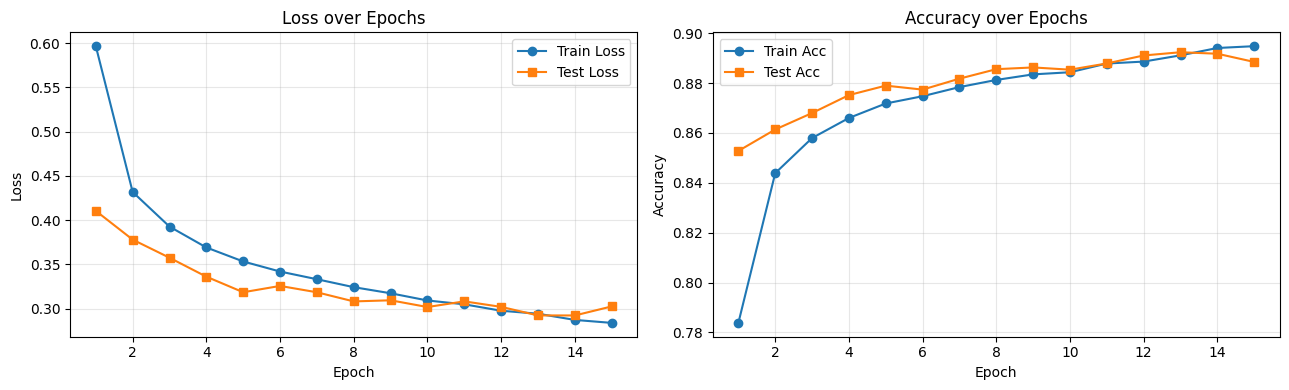


Best Test Accuracy: 0.8924


In [10]:
epochs = range(1, NUM_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Loss
ax1.plot(epochs, history['train_loss'], label='Train Loss', marker='o')
ax1.plot(epochs, history['test_loss'],  label='Test Loss',  marker='s')
ax1.set_title('Loss over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(epochs, history['train_acc'], label='Train Acc', marker='o')
ax2.plot(epochs, history['test_acc'],  label='Test Acc',  marker='s')
ax2.set_title('Accuracy over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nBest Test Accuracy: {max(history['test_acc']):.4f}")

## 10. Inspect Predictions

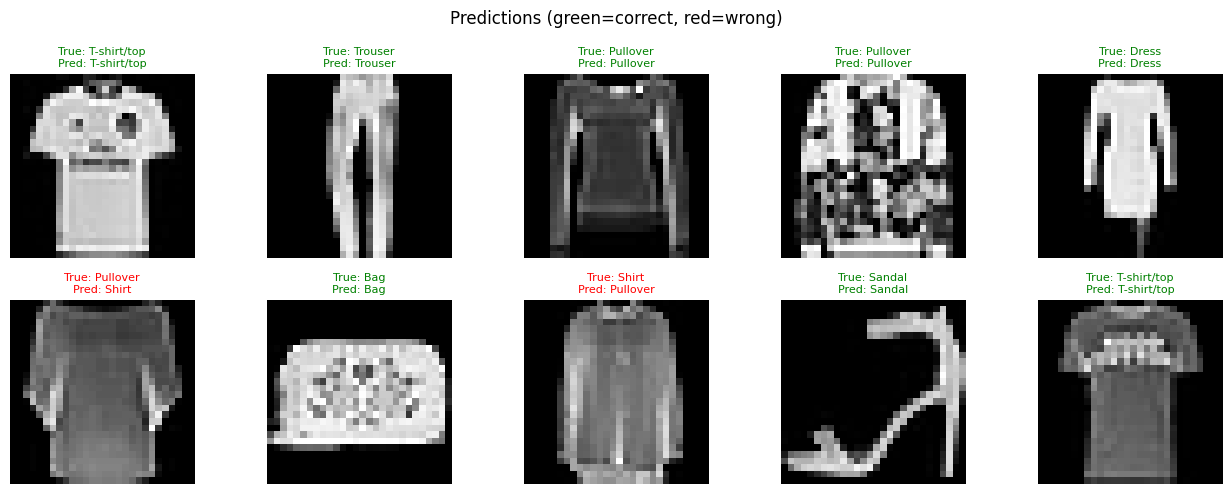

In [11]:
model.eval()
images, labels = next(iter(test_loader))
images_dev = images.to(device)

with torch.no_grad():
    outputs = model(images_dev)
    preds   = outputs.argmax(dim=1).cpu()

# Show first 10
fig, axes = plt.subplots(2, 5, figsize=(13, 5))
for i, ax in enumerate(axes.flat):
    img   = images[i].reshape(28, 28).numpy()
    true  = CLASS_NAMES[labels[i].item()]
    pred  = CLASS_NAMES[preds[i].item()]
    color = 'green' if true == pred else 'red'
    ax.imshow(img, cmap='gray')
    ax.set_title(f'True: {true}\nPred: {pred}', color=color, fontsize=8)
    ax.axis('off')

plt.suptitle('Predictions (green=correct, red=wrong)', fontsize=12)
plt.tight_layout()
plt.show()

## 11. Save & Load the Model

In [12]:
# Save only the weights (recommended)
torch.save(model.state_dict(), 'fashion_mlp.pth')
print("Model saved to fashion_mlp.pth")

# To reload later:
# loaded_model = MLP()
# loaded_model.load_state_dict(torch.load('fashion_mlp.pth'))
# loaded_model.to(device)
# loaded_model.eval()

Model saved to fashion_mlp.pth


## Summary — The Full Picture

```
FORWARD PASS
Input (784) → Linear → ReLU → Dropout → Linear → ReLU → Dropout → Linear → Logits (10)
                                                                               ↓
                                                                    CrossEntropyLoss
                                                                               ↓
BACKWARD PASS                                                            scalar loss
loss.backward() ← chain rule walks the graph backwards → fills .grad on every weight
                                                                               ↓
optimizer.step() → w = w - lr * w.grad  (Adam adjusts lr per parameter adaptively)
```

**What to try next:**
- Add `BatchNorm1d` after each Linear layer — usually boosts accuracy
- Try a CNN instead of MLP — Conv layers exploit spatial structure in images
- Add a learning rate scheduler (`CosineAnnealingLR`) — improves final accuracy
- Log with Weights & Biases for experiment tracking